# Brain MRI Tissue Segmentation — Multi-Class Semantic Segmentation
## VGG16 + UNet++ | 4-Class (Background / CSF / Grey Matter / White Matter) | MRBrainS18 Dataset

**Dataset:** MRBrainS18 Challenge Dataset — 7 labeled training subjects, multi-sequence MRI (T1, FLAIR, IR). Only the `training` split is used since the `test` split has no publicly released segmentation labels.

**Label Remapping:** MRBrainS18 uses 9 classes which are consolidated into 4 tissue classes:
- 0 → Background
- 1, 2, 8 → Grey Matter (cortical GM + basal ganglia + brainstem/cerebellum)
- 3, 4 → White Matter (WM + WM lesions)
- 5, 6, 7 → CSF (ventricular CSF + vessels + external CSF)

**Training Notes:**
- Only 7 labeled subjects are available; therefore, every slice (`step=1`) is used to maximize the training dataset.
- Strong data augmentation is applied to improve model generalization.
- EarlyStopping is disabled so the model trains for the full configured number of epochs.

## 1. Import Libraries

In [5]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, UpSampling2D, concatenate,
    BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [6]:
# ─── Paths ────────────────────────────────────────────────────────────────────
TRAIN_ROOT = '/kaggle/input/datasets/mahi789/trainingg/training'
# Note: test split excluded — no public segmentation labels available

PROCESSED_DIR  = 'mrbrains_processed'
IMAGE_FOLDER   = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER    = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR  = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR   = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR  = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 8    # smaller batch — fewer total slices than OASIS/IBSR
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.20  # slightly larger test split given small dataset
NUM_CLASSES = 4
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

# ─── MRBrainS18 label remapping ───────────────────────────────────────────────
# Original 9 classes → 4 standard tissue classes (matches OASIS-1 and IBSR)
MRBRAINS_REMAP = {
    0: 0,  # Background
    1: 2,  # Cortical Grey Matter → GM
    2: 2,  # Basal Ganglia → GM
    3: 3,  # White Matter → WM
    4: 3,  # White Matter Lesions → WM
    5: 1,  # Ventricular CSF → CSF
    6: 1,  # Vessels/Choroid Plexus → CSF
    7: 1,  # External CSF/Sulci → CSF
    8: 2,  # Brainstem + Cerebellum → GM
}

print('Config set ✓')
print('Label remapping:', MRBRAINS_REMAP)

Config set ✓
Label remapping: {0: 0, 1: 2, 2: 2, 3: 3, 4: 3, 5: 1, 6: 1, 7: 1, 8: 2}


## 3. Extract 2D Slices — Remap 9 Classes to 4

In [7]:
for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready ✓')

Directories ready ✓


In [8]:
def extract_slices_mrbrains(subject_dir, subject_name, img_out, mask_out, step=1):
    """
    MRBrainS18 file structure:
      <subject>/orig/reg_T1.nii  - Registered T1 MRI
      <subject>/segm.nii         - Segmentation mask

    Both have shape (240, 240, 48).
    """

    # Use REGISTERED T1 (same space as segmentation)
    t1_path = os.path.join(subject_dir, "orig", "reg_T1.nii")
    seg_path = os.path.join(subject_dir, "segm.nii")

    # Fallback to .nii.gz
    if not os.path.exists(t1_path):
        t1_path = os.path.join(subject_dir, "orig", "reg_T1.nii.gz")

    if not os.path.exists(seg_path):
        seg_path = os.path.join(subject_dir, "segm.nii.gz")

    if not os.path.exists(t1_path) or not os.path.exists(seg_path):
        print(f"Skipping {subject_name} - missing reg_T1.nii or segm.nii")
        return 0

    brain_vol = np.squeeze(nib.load(t1_path).get_fdata())
    seg_vol = np.squeeze(nib.load(seg_path).get_fdata())

    print(f"{subject_name} -> brain: {brain_vol.shape}, seg: {seg_vol.shape}")

    saved = 0

    # Both volumes have the same shape (240,240,48)
    for i in range(0, brain_vol.shape[2], step):

        b_sl = brain_vol[:, :, i]
        seg_sl = seg_vol[:, :, i]

        # Skip empty MRI slices
        if b_sl.max() == 0:
            continue

        img_arr = normalize_slice(b_sl)

        mask_arr = remap_labels(
            np.round(seg_sl).astype(np.uint8),
            MRBRAINS_REMAP
        )

        fname = f"{subject_name}_sl{i:03d}.png"

        cv2.imwrite(os.path.join(img_out, fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)

        saved += 1

    return saved

## 4. Verify Label Remapping & Visualize

In [9]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')

Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


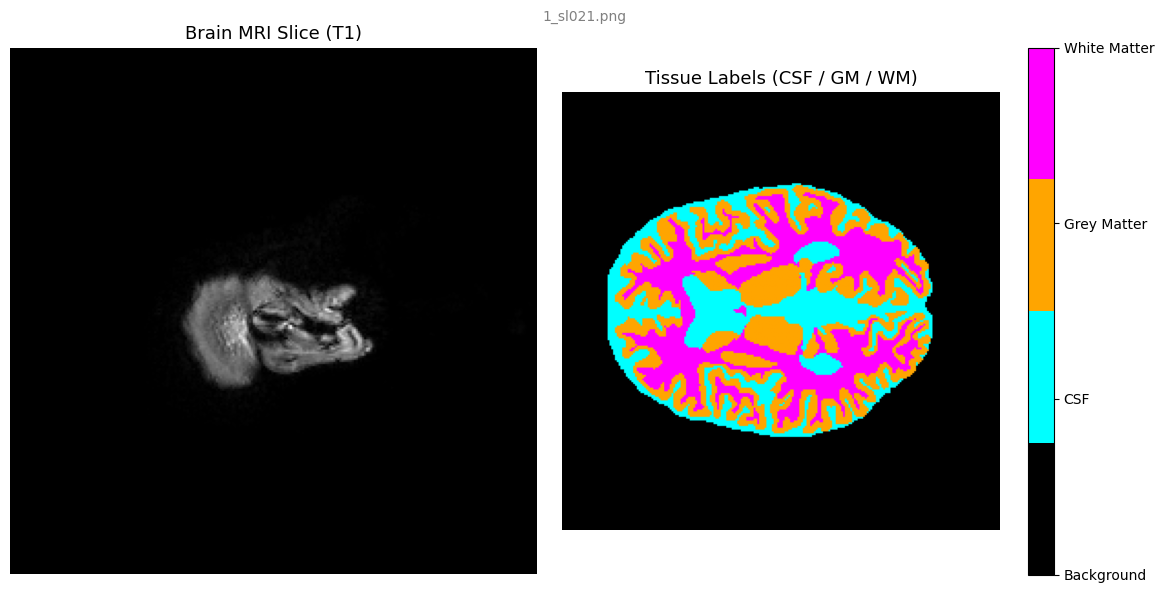

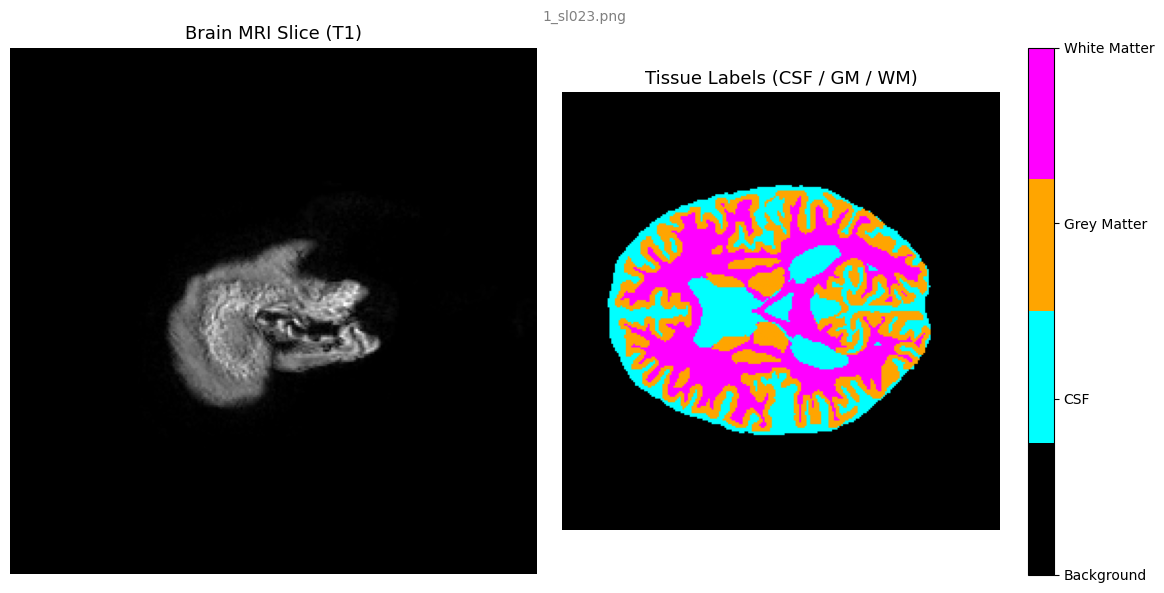

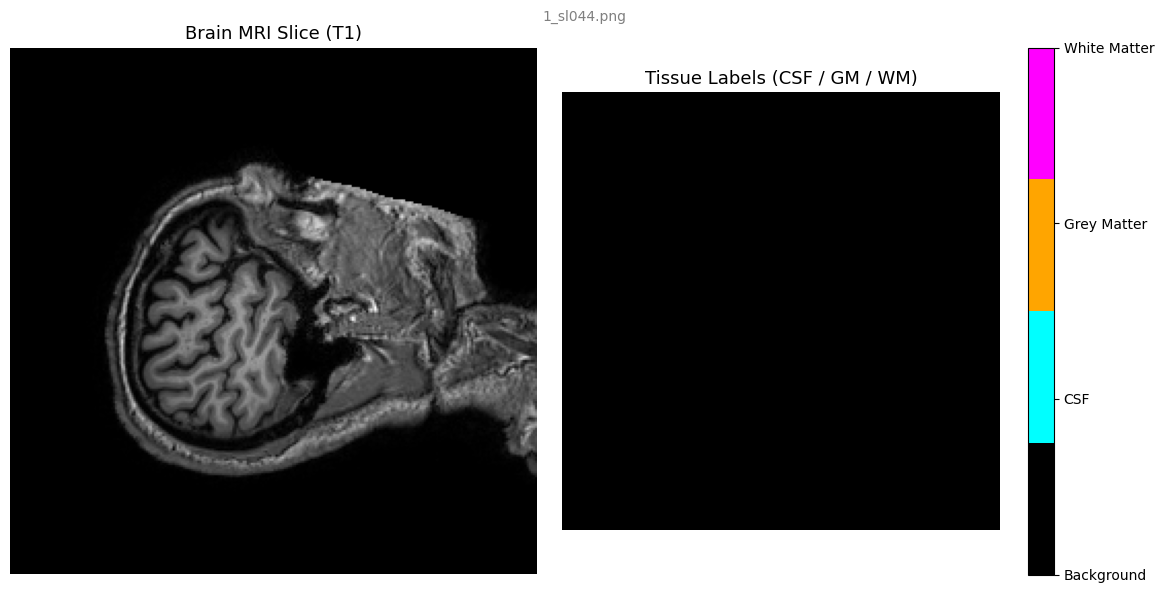

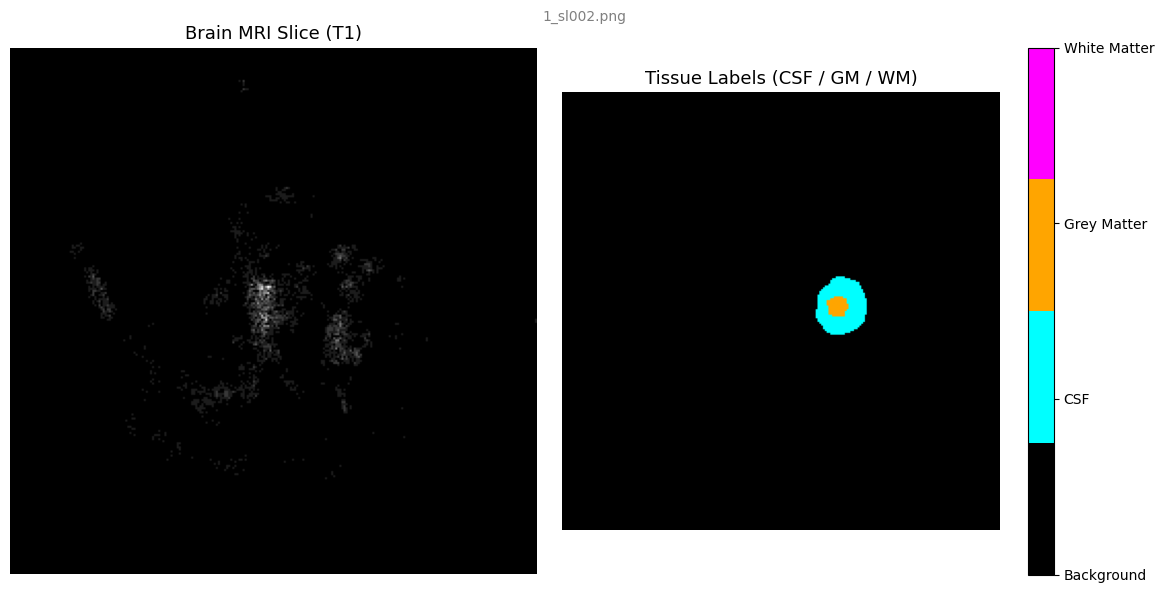

In [10]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample(image_name):
    img  = cv2.imread(os.path.join(IMAGE_FOLDER, image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(MASK_FOLDER,  image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Brain MRI Slice (T1)', fontsize=13)

    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)

    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [11]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch!'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 38  |  Test: 10


  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline — with stronger augmentation (small dataset)

In [12]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)
    return img, mask


def augment(img, mask):
    # Stronger augmentation since dataset is small (7 subjects)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes → images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1783278106.861055      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes → images: (8, 224, 224, 3)  masks: (8, 224, 224, 4)


## 7. Model — VGG16 Encoder + UNet++ (Nested) Decoder, 4-class softmax output
**UNet++ adds dense nested skip pathways** instead of single skip connections per level.

In [13]:
def conv_block(x, filters, name_prefix):
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x

def up(x, name): return UpSampling2D((2,2), name=name)(x)

def build_model(input_shape=(224,224,3), num_classes=4, freeze_encoder=True):
    inputs = Input(shape=input_shape, name='input')
    base = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)
    if freeze_encoder:
        for layer in base.layers: layer.trainable = False
    X00=base.get_layer('block1_conv2').output
    X10=base.get_layer('block2_conv2').output
    X20=base.get_layer('block3_conv3').output
    X30=base.get_layer('block4_conv3').output
    X40=base.get_layer('block5_conv3').output
    F=[64,128,256,512,512]
    X01=conv_block(concatenate([X00,up(X10,'up10_01')]),F[0],'X01')
    X11=conv_block(concatenate([X10,up(X20,'up20_11')]),F[1],'X11')
    X21=conv_block(concatenate([X20,up(X30,'up30_21')]),F[2],'X21')
    X31=conv_block(concatenate([X30,up(X40,'up40_31')]),F[3],'X31')
    X02=conv_block(concatenate([X00,X01,up(X11,'up11_02')]),F[0],'X02')
    X12=conv_block(concatenate([X10,X11,up(X21,'up21_12')]),F[1],'X12')
    X22=conv_block(concatenate([X20,X21,up(X31,'up31_22')]),F[2],'X22')
    X03=conv_block(concatenate([X00,X01,X02,up(X12,'up12_03')]),F[0],'X03')
    X13=conv_block(concatenate([X10,X11,X12,up(X22,'up22_13')]),F[1],'X13')
    X04=conv_block(concatenate([X00,X01,X02,X03,up(X13,'up13_04')]),F[0],'X04')
    output=Conv2D(num_classes,(1,1),activation='softmax',name='output')(X04)
    return Model(inputs=inputs,outputs=output,name='VGG16_UNetPP_MultiClass_MRBrainS18')

model=build_model(input_shape=(*IMG_SIZE,3),num_classes=NUM_CLASSES)
print('Model built')
print(f'Total parameters     : {model.count_params():,}')
print(f'Trainable parameters : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model built
Total parameters     : 30,140,740
Trainable parameters : 15,419,396


## 8. Custom Metrics & Loss

In [14]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    return K.mean((2.0 * intersection + smooth) / (union + smooth))

def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)

def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    return K.mean((intersection + smooth) / (total + smooth))

def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def pixel_accuracy_multiclass(y_true, y_pred):
    return K.mean(K.cast(K.equal(K.argmax(y_true, axis=-1), K.argmax(y_pred, axis=-1)), K.floatx()))

def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass,
             pixel_accuracy_multiclass, csf_iou, gm_iou, wm_iou]
)
print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [15]:
model.summary()
try:
    tf.keras.utils.plot_model(model, to_file='vgg16_unetpp_mrbrains_architecture.png',
                               show_shapes=True, show_layer_names=True, dpi=64)
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:100])

Model: "VGG16_UNetPP_MultiClass_MRBrainS18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 30,140,740 (114.98 MB)

 Trainable params: 15,419,396 (58.82 MB)

 Non-trainable params: 14,721,344 (56.16 MB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [16]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)

def colorize_mask(label_map):
    colors = np.array([[0,0,0],[0,255,255],[255,165,0],[255,0,255]], dtype=np.uint8)
    return colors[np.array(label_map).astype(int)]

def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            fig, axes = plt.subplots(1, 3, figsize=(13, 4))
            axes[0].imshow(imgs[i].numpy());                              axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(decode_mask(masks[i]).numpy())); axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(decode_mask(preds[i]).numpy())); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show()

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_vgg16unetpp_mrbrains.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed
]
print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1783278133.648407     141 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


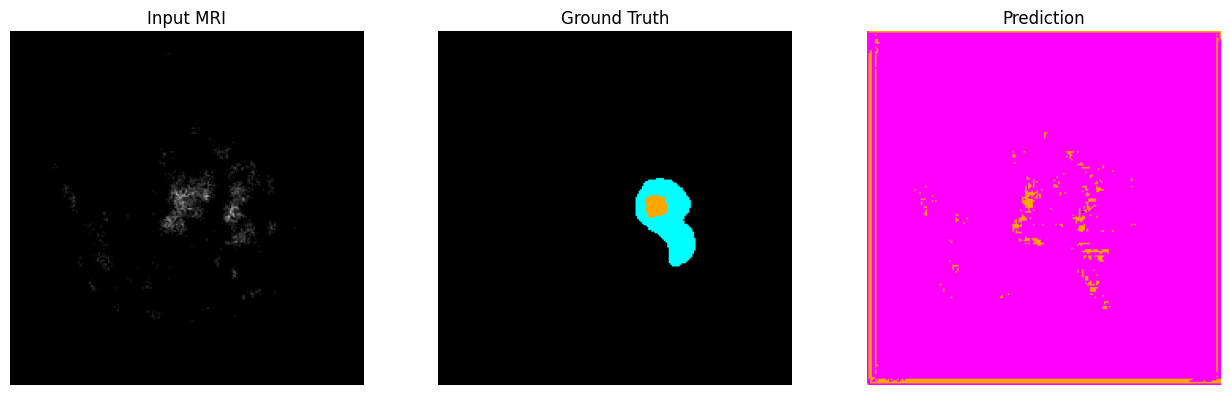

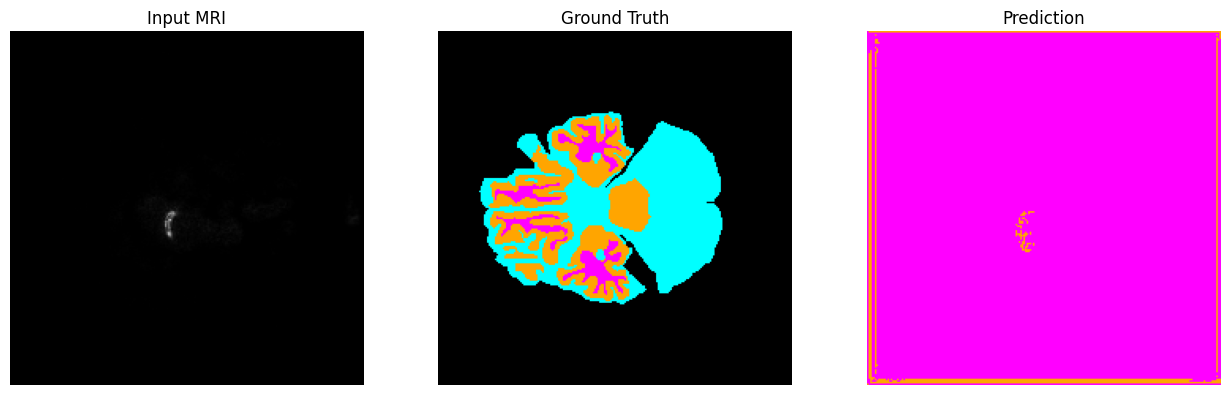

In [17]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 4
Validation steps : 1
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - csf_iou: 0.0523 - dice_coefficient_multiclass: 0.1314 - gm_iou: 0.0483 - iou_score_multiclass: 0.0740 - loss: 2.8181 - pixel_accuracy_multiclass: 0.0773 - wm_iou: 0.0286
Epoch 1: val_iou_score_multiclass improved from None to 0.04178, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 1: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - csf_iou: 0.0596 - dice_coefficient_multiclass: 0.1596 - gm_iou: 0.0700 - iou_score_multiclass: 0.0905 - loss: 2.6334 - pixel_accuracy_multiclass: 0.1018 - wm_iou: 0.0452 - val_csf_iou: 0.0074 - val_dice_coefficient_multiclass: 0.0777 - val_gm_iou: 0.0751 - val_iou_score_multiclass: 0.0418 - val_loss: 7.1504 - val_pixel_accuracy_multiclass: 0.0934 - val_wm_iou: 0.0831 - learning_rate: 1.0000e-04
Epoch 2/100


2026-07-05 19:03:13.070743: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:03:13.315902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:03:16.968627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:03:17.232720: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:03:21.459484: E external/local_xla/xla/stream_

1/4 ━━━━━━━━━━━━━━━━━━━━ 1:52 38s/step - csf_iou: 0.0090 - dice_coefficient_multiclass: 0.0845 - gm_iou: 0.0023 - iou_score_multiclass: 0.0497 - loss: 3.1115 - pixel_accuracy_multiclass: 0.0855 - wm_iou: 1.2611e-04
Epoch 2: val_iou_score_multiclass improved from 0.04178 to 0.04210, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 2: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - csf_iou: 0.0090 - dice_coefficient_multiclass: 0.0845 - gm_iou: 0.0023 - iou_score_multiclass: 0.0497 - loss: 3.1115 - pixel_accuracy_multiclass: 0.0855 - wm_iou: 1.2611e-04 - val_csf_iou: 0.0076 - val_dice_coefficient_multiclass: 0.0783 - val_gm_iou: 0.0770 - val_iou_score_multiclass: 0.0421 - val_loss: 7.2775 - val_pixel_accuracy_multiclass: 0.0910 - val_wm_iou: 0.0823 - learning_rate: 1.0000e-04
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - csf_iou: 0.0613 - dice_coefficient_multiclass: 0.1766 - gm_iou: 0.0574 - iou_score_multiclass: 0

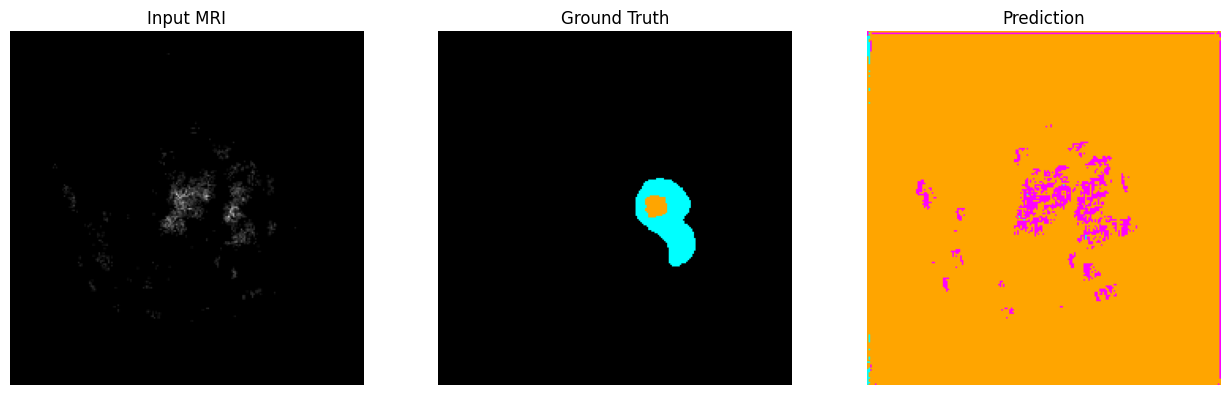

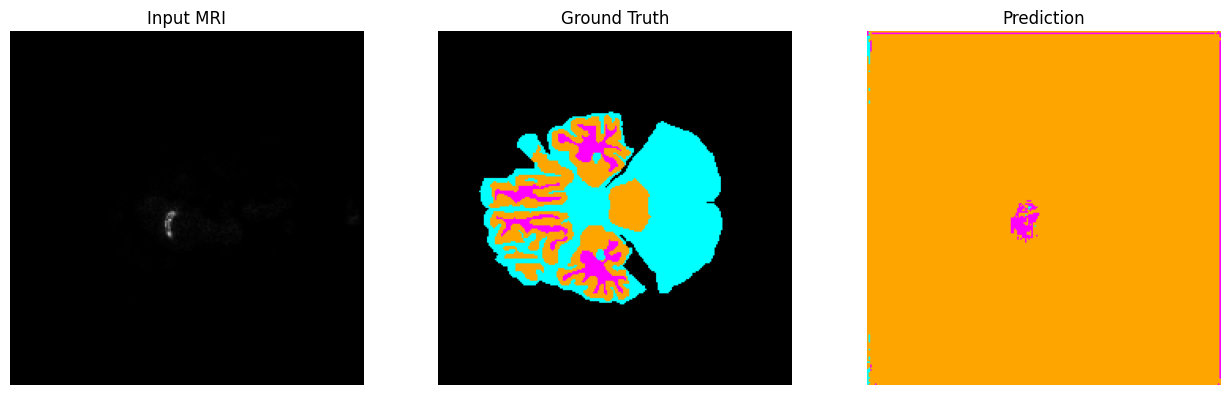

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass did not improve from 0.05166
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - csf_iou: 0.0129 - dice_coefficient_multiclass: 0.1297 - gm_iou: 0.0027 - iou_score_multiclass: 0.0846 - loss: 2.6331 - pixel_accuracy_multiclass: 0.5992 - wm_iou: 1.4287e-04 - val_csf_iou: 0.0394 - val_dice_coefficient_multiclass: 0.0954 - val_gm_iou: 0.0756 - val_iou_score_multiclass: 0.0512 - val_loss: 7.6127 - val_pixel_accuracy_multiclass: 0.0888 - val_wm_iou: 0.0878 - learning_rate: 5.0000e-05
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - csf_iou: 0.0751 - dice_coefficient_multiclass: 0.2291 - gm_iou: 0.0654 - iou_score_multiclass: 0.1500 - loss: 1.9348 - pixel_accuracy_multiclass: 0.7660 - wm_iou: 0.0327
Epoch 11: val_iou_score_multiclass did not improve from 0.05166

Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - csf_iou: 0.0849 - dice_coefficient_multiclass: 0.2541 - gm_iou: 

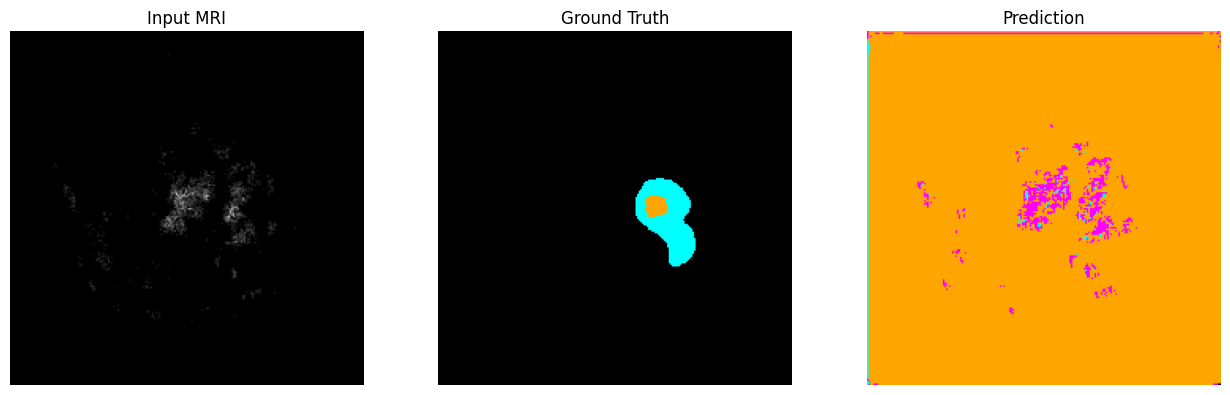

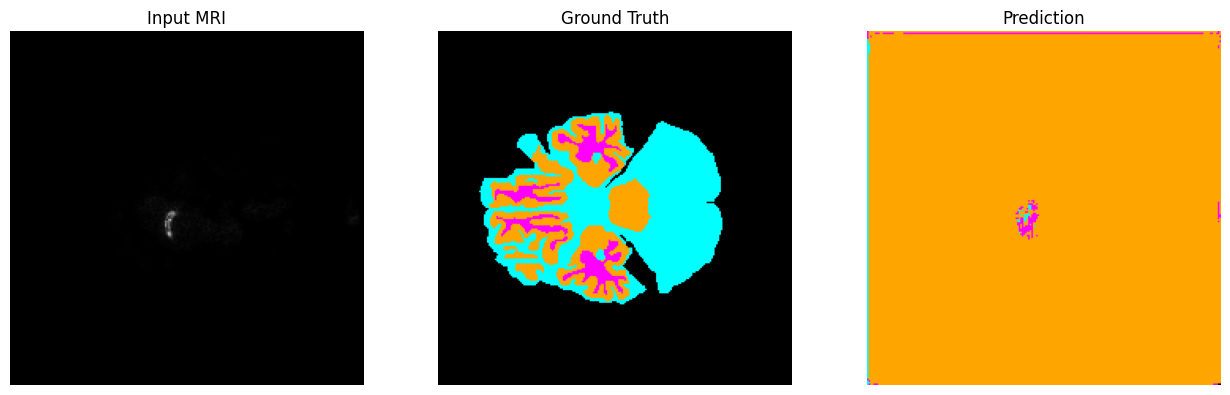

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass improved from 0.05445 to 0.05464, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 20: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0140 - dice_coefficient_multiclass: 0.1388 - gm_iou: 0.0025 - iou_score_multiclass: 0.0926 - loss: 2.4807 - pixel_accuracy_multiclass: 0.6240 - wm_iou: 1.7204e-04 - val_csf_iou: 0.0511 - val_dice_coefficient_multiclass: 0.1022 - val_gm_iou: 0.0767 - val_iou_score_multiclass: 0.0546 - val_loss: 5.5193 - val_pixel_accuracy_multiclass: 0.0893 - val_wm_iou: 0.0806 - learning_rate: 2.5000e-05
Epoch 21/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - csf_iou: 0.0873 - dice_coefficient_multiclass: 0.2497 - gm_iou: 0.0730 - iou_score_multiclass: 0.1675 - loss: 1.7848 - pixel_accuracy_multiclass: 0.7816 - wm_iou: 0.0346
Epoch 21: val_iou_score_multiclass improved from 0.05464 to 0.05535, saving model to best_model_vgg16unetpp_mrb

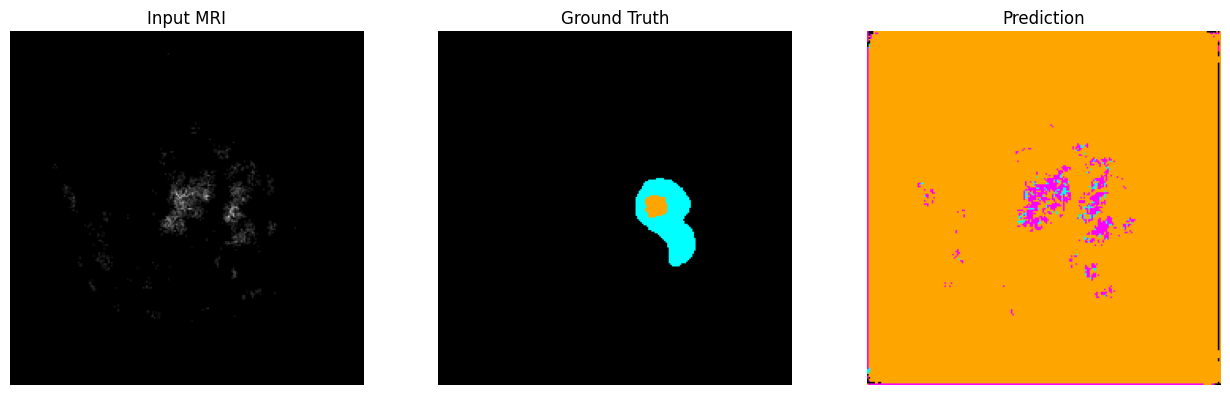

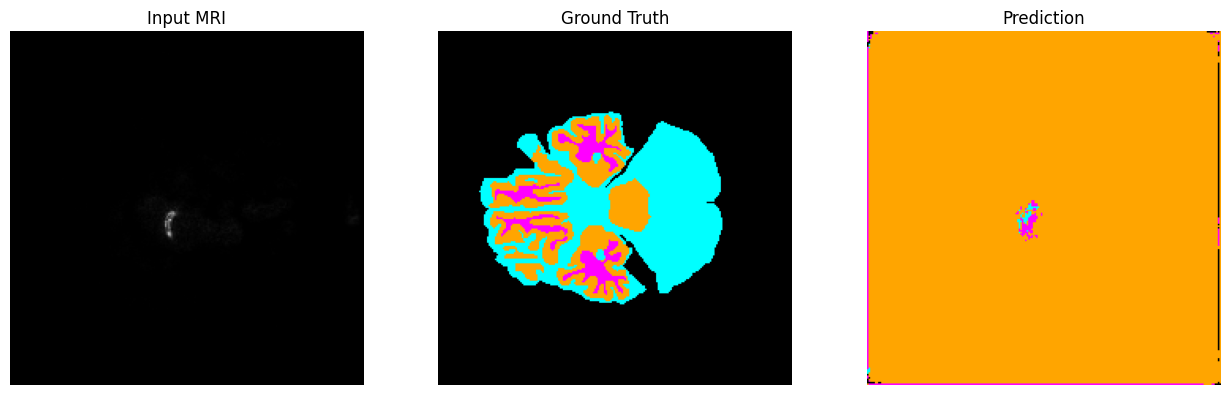

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass improved from 0.06055 to 0.06096, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 30: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0152 - dice_coefficient_multiclass: 0.1462 - gm_iou: 0.0026 - iou_score_multiclass: 0.0992 - loss: 2.3691 - pixel_accuracy_multiclass: 0.6429 - wm_iou: 1.8876e-04 - val_csf_iou: 0.0569 - val_dice_coefficient_multiclass: 0.1142 - val_gm_iou: 0.0773 - val_iou_score_multiclass: 0.0610 - val_loss: 4.5343 - val_pixel_accuracy_multiclass: 0.0943 - val_wm_iou: 0.0807 - learning_rate: 2.5000e-05
Epoch 31/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - csf_iou: 0.0928 - dice_coefficient_multiclass: 0.2635 - gm_iou: 0.0794 - iou_score_multiclass: 0.1800 - loss: 1.6787 - pixel_accuracy_multiclass: 0.8007 - wm_iou: 0.0371
Epoch 31: val_iou_score_multiclass improved from 0.06096 to 0.06238, saving model to best_model_vgg16unetpp_mrb

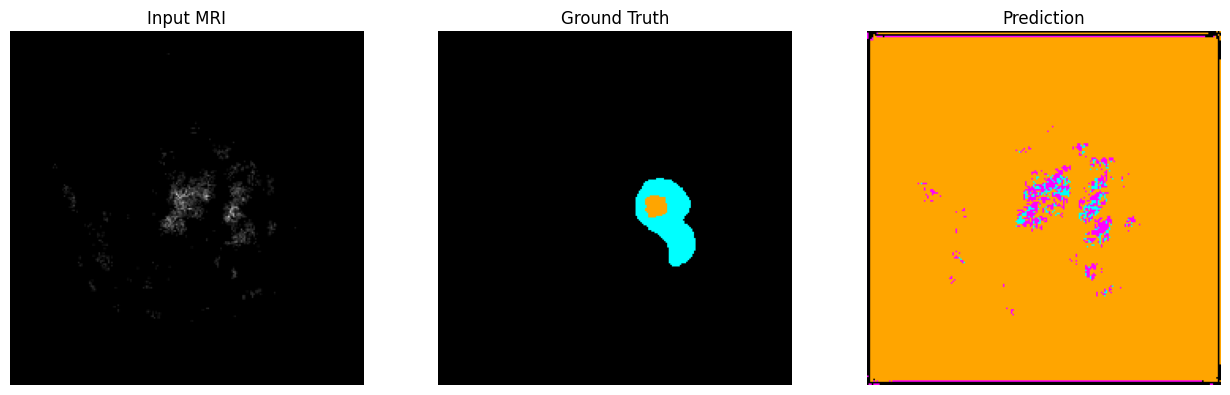

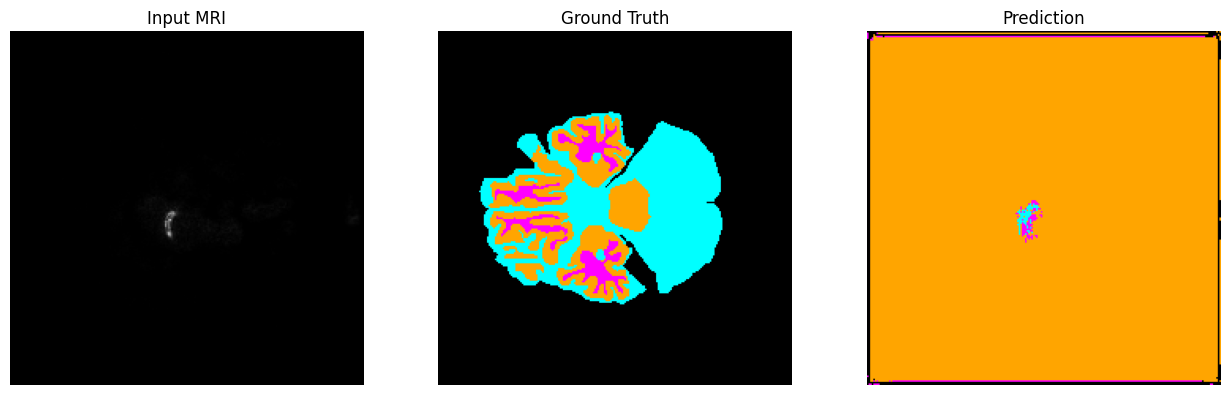

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass improved from 0.06893 to 0.06925, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 40: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0158 - dice_coefficient_multiclass: 0.1530 - gm_iou: 0.0028 - iou_score_multiclass: 0.1056 - loss: 2.2483 - pixel_accuracy_multiclass: 0.6724 - wm_iou: 1.8608e-04 - val_csf_iou: 0.0647 - val_dice_coefficient_multiclass: 0.1294 - val_gm_iou: 0.0781 - val_iou_score_multiclass: 0.0693 - val_loss: 3.8415 - val_pixel_accuracy_multiclass: 0.1225 - val_wm_iou: 0.0784 - learning_rate: 2.5000e-05
Epoch 41/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - csf_iou: 0.1010 - dice_coefficient_multiclass: 0.2765 - gm_iou: 0.0827 - iou_score_multiclass: 0.1919 - loss: 1.5743 - pixel_accuracy_multiclass: 0.8264 - wm_iou: 0.0404
Epoch 41: val_iou_score_multiclass improved from 0.06925 to 0.07084, saving model to best_model_vgg16unetpp_mrb

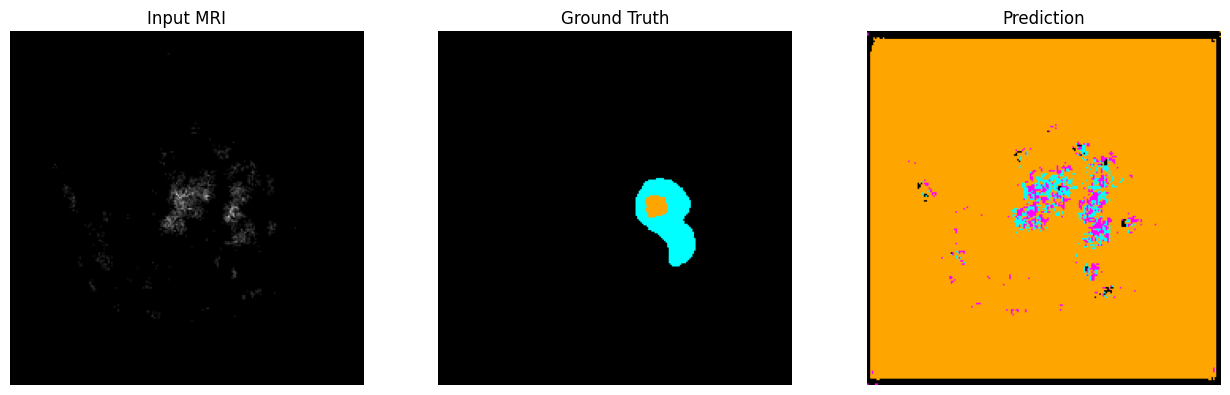

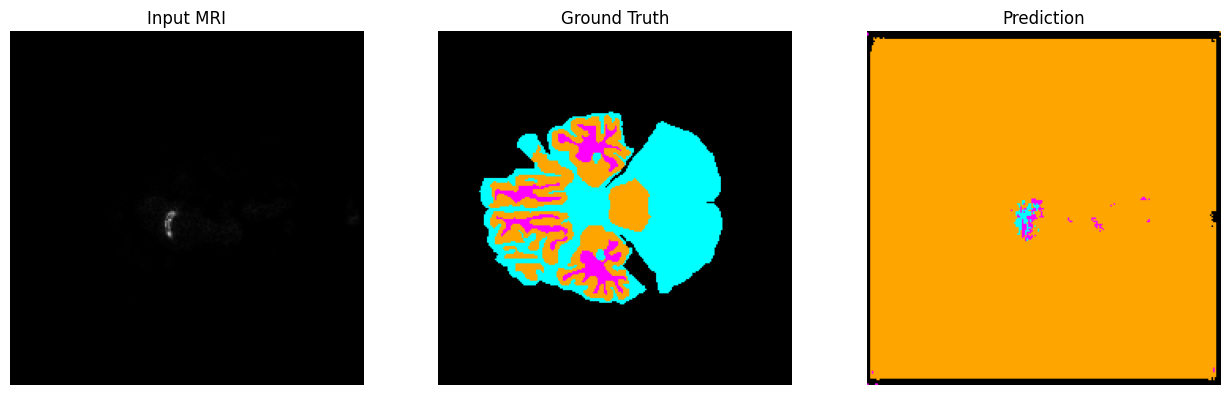

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass improved from 0.08000 to 0.08057, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 50: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0165 - dice_coefficient_multiclass: 0.1587 - gm_iou: 0.0029 - iou_score_multiclass: 0.1110 - loss: 2.1447 - pixel_accuracy_multiclass: 0.7010 - wm_iou: 2.1854e-04 - val_csf_iou: 0.0709 - val_dice_coefficient_multiclass: 0.1489 - val_gm_iou: 0.0777 - val_iou_score_multiclass: 0.0806 - val_loss: 3.1836 - val_pixel_accuracy_multiclass: 0.1537 - val_wm_iou: 0.0743 - learning_rate: 2.5000e-05
Epoch 51/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - csf_iou: 0.1121 - dice_coefficient_multiclass: 0.2911 - gm_iou: 0.0864 - iou_score_multiclass: 0.2051 - loss: 1.4792 - pixel_accuracy_multiclass: 0.8361 - wm_iou: 0.0448
Epoch 51: val_iou_score_multiclass improved from 0.08057 to 0.08249, saving model to best_model_vgg16unetpp_mrb

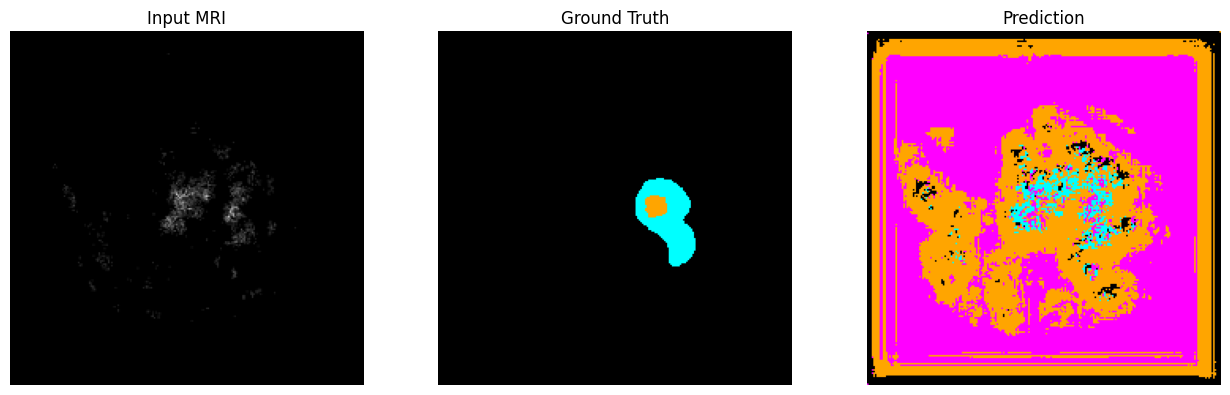

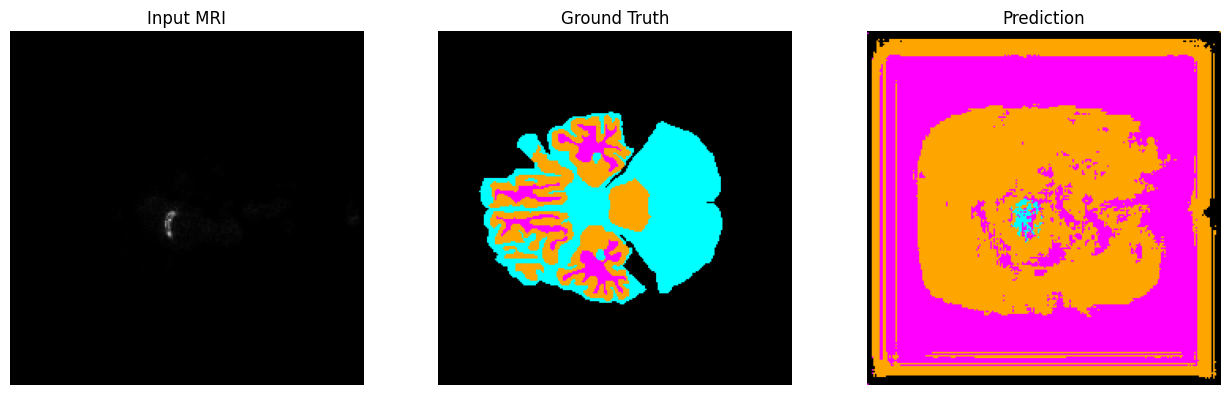

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass improved from 0.09902 to 0.10036, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 60: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0159 - dice_coefficient_multiclass: 0.1645 - gm_iou: 0.0035 - iou_score_multiclass: 0.1171 - loss: 2.0195 - pixel_accuracy_multiclass: 0.7420 - wm_iou: 2.1246e-04 - val_csf_iou: 0.0755 - val_dice_coefficient_multiclass: 0.1799 - val_gm_iou: 0.0784 - val_iou_score_multiclass: 0.1004 - val_loss: 2.5841 - val_pixel_accuracy_multiclass: 0.1750 - val_wm_iou: 0.0747 - learning_rate: 2.5000e-05
Epoch 61/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - csf_iou: 0.1195 - dice_coefficient_multiclass: 0.3019 - gm_iou: 0.0897 - iou_score_multiclass: 0.2152 - loss: 1.3808 - pixel_accuracy_multiclass: 0.8652 - wm_iou: 0.0485
Epoch 61: val_iou_score_multiclass improved from 0.10036 to 0.10519, saving model to best_model_vgg16unetpp_mrb

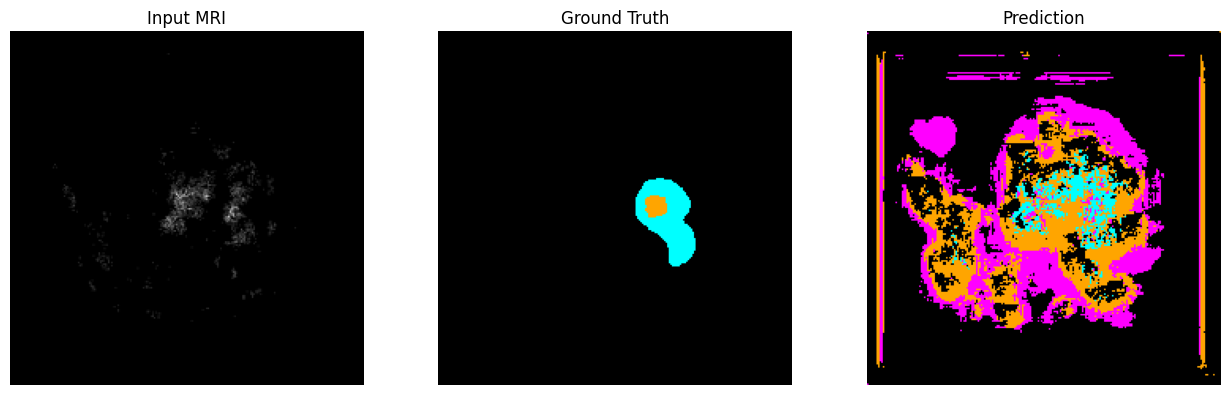

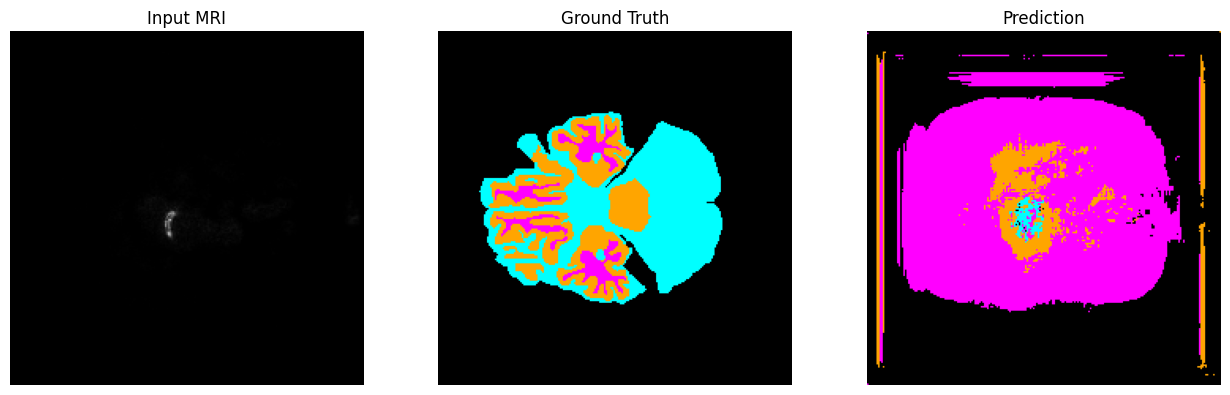

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass improved from 0.13724 to 0.13982, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 70: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0166 - dice_coefficient_multiclass: 0.1716 - gm_iou: 0.0038 - iou_score_multiclass: 0.1243 - loss: 1.8994 - pixel_accuracy_multiclass: 0.7784 - wm_iou: 3.1898e-04 - val_csf_iou: 0.0792 - val_dice_coefficient_multiclass: 0.2326 - val_gm_iou: 0.0838 - val_iou_score_multiclass: 0.1398 - val_loss: 1.9868 - val_pixel_accuracy_multiclass: 0.5937 - val_wm_iou: 0.0807 - learning_rate: 2.5000e-05
Epoch 71/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - csf_iou: 0.1287 - dice_coefficient_multiclass: 0.3086 - gm_iou: 0.0895 - iou_score_multiclass: 0.2209 - loss: 1.3412 - pixel_accuracy_multiclass: 0.8772 - wm_iou: 0.0513
Epoch 71: val_iou_score_multiclass improved from 0.13982 to 0.14783, saving model to best_model_vgg16unetpp_mrb

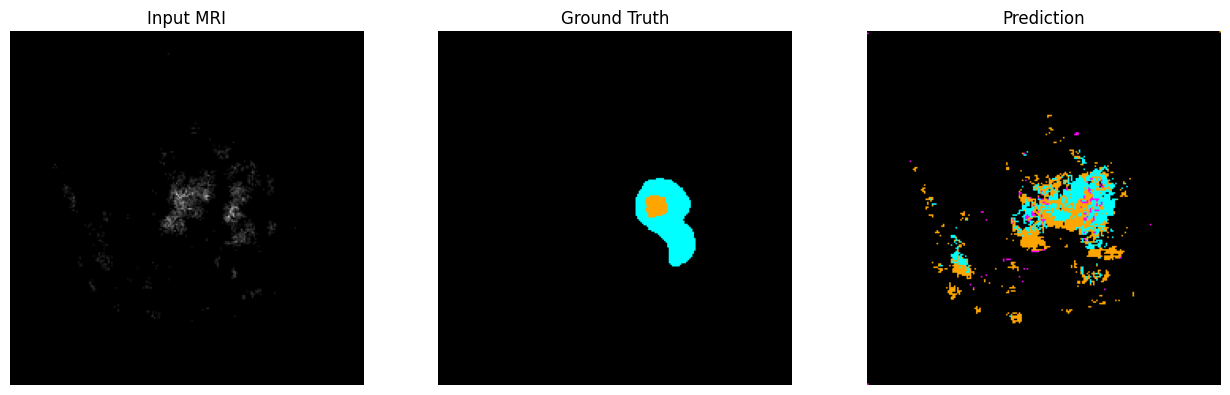

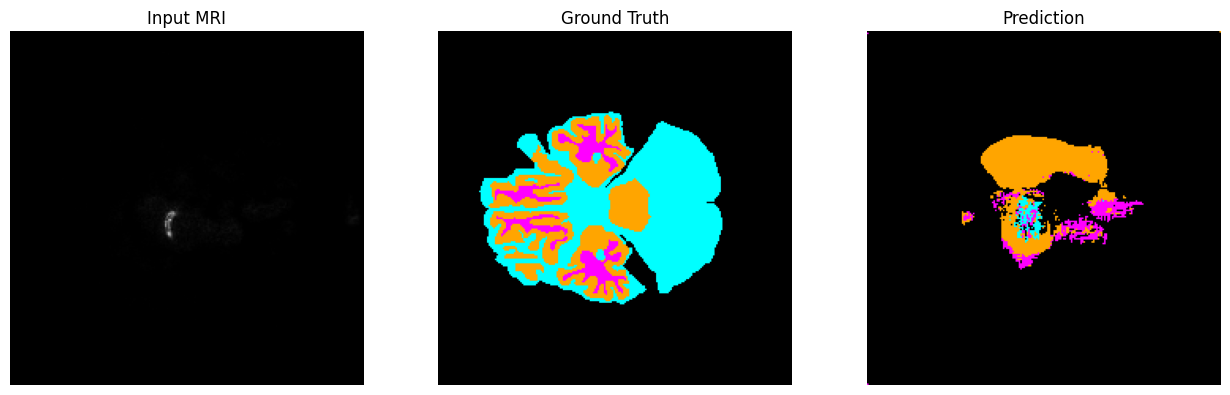

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass improved from 0.18355 to 0.18487, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 80: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0186 - dice_coefficient_multiclass: 0.1800 - gm_iou: 0.0043 - iou_score_multiclass: 0.1330 - loss: 1.8115 - pixel_accuracy_multiclass: 0.8413 - wm_iou: 2.2009e-04 - val_csf_iou: 0.0863 - val_dice_coefficient_multiclass: 0.2836 - val_gm_iou: 0.0924 - val_iou_score_multiclass: 0.1849 - val_loss: 1.6218 - val_pixel_accuracy_multiclass: 0.7800 - val_wm_iou: 0.0913 - learning_rate: 2.5000e-05
Epoch 81/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - csf_iou: 0.1473 - dice_coefficient_multiclass: 0.3271 - gm_iou: 0.0978 - iou_score_multiclass: 0.2366 - loss: 1.2622 - pixel_accuracy_multiclass: 0.8837 - wm_iou: 0.0572
Epoch 81: val_iou_score_multiclass improved from 0.18487 to 0.19069, saving model to best_model_vgg16unetpp_mrb

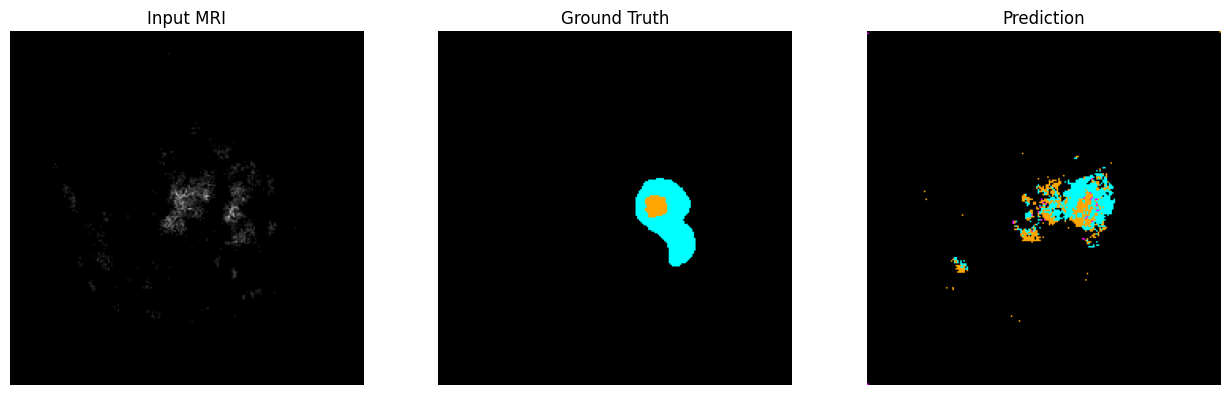

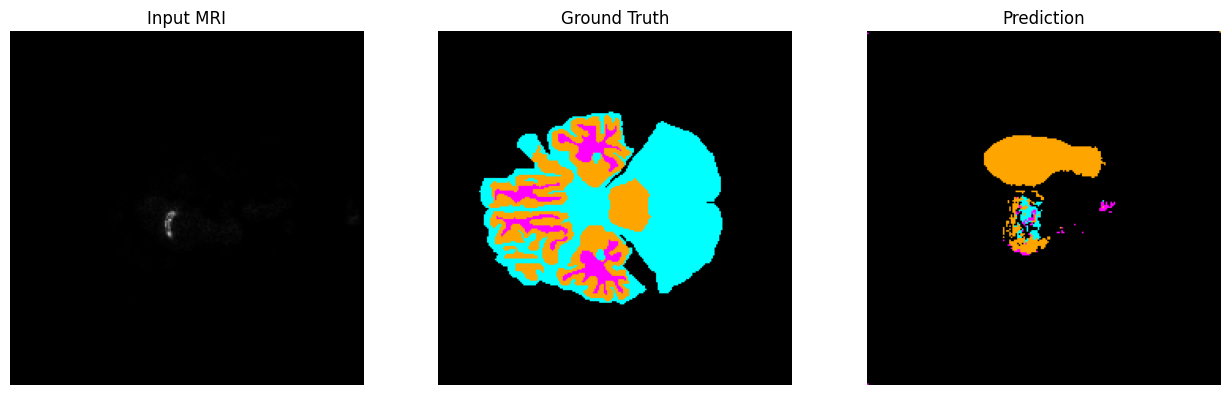

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass improved from 0.21211 to 0.21301, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 90: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0167 - dice_coefficient_multiclass: 0.1794 - gm_iou: 0.0048 - iou_score_multiclass: 0.1327 - loss: 1.7654 - pixel_accuracy_multiclass: 0.8297 - wm_iou: 2.5868e-04 - val_csf_iou: 0.0921 - val_dice_coefficient_multiclass: 0.3120 - val_gm_iou: 0.1013 - val_iou_score_multiclass: 0.2130 - val_loss: 1.4471 - val_pixel_accuracy_multiclass: 0.7839 - val_wm_iou: 0.0959 - learning_rate: 2.5000e-05
Epoch 91/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - csf_iou: 0.1617 - dice_coefficient_multiclass: 0.3379 - gm_iou: 0.1009 - iou_score_multiclass: 0.2461 - loss: 1.2212 - pixel_accuracy_multiclass: 0.8912 - wm_iou: 0.0611
Epoch 91: val_iou_score_multiclass improved from 0.21301 to 0.21715, saving model to best_model_vgg16unetpp_mrb

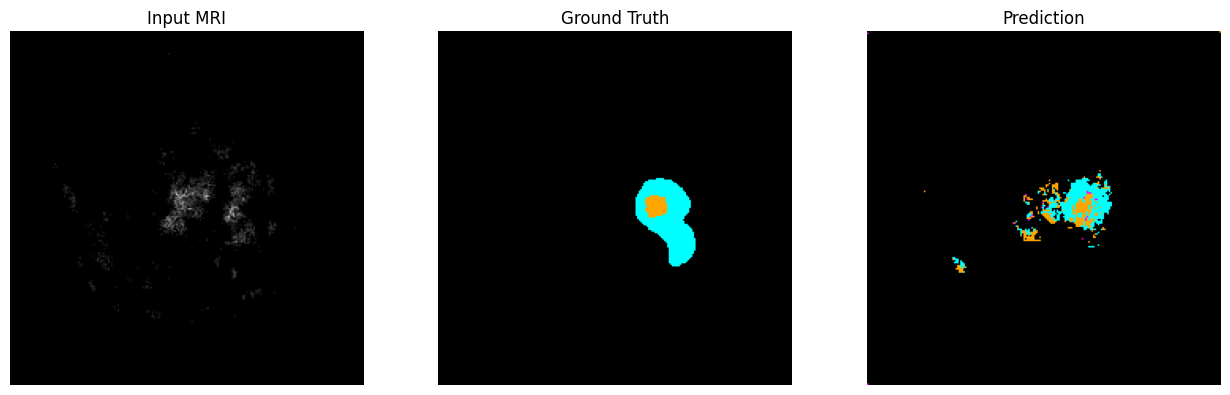

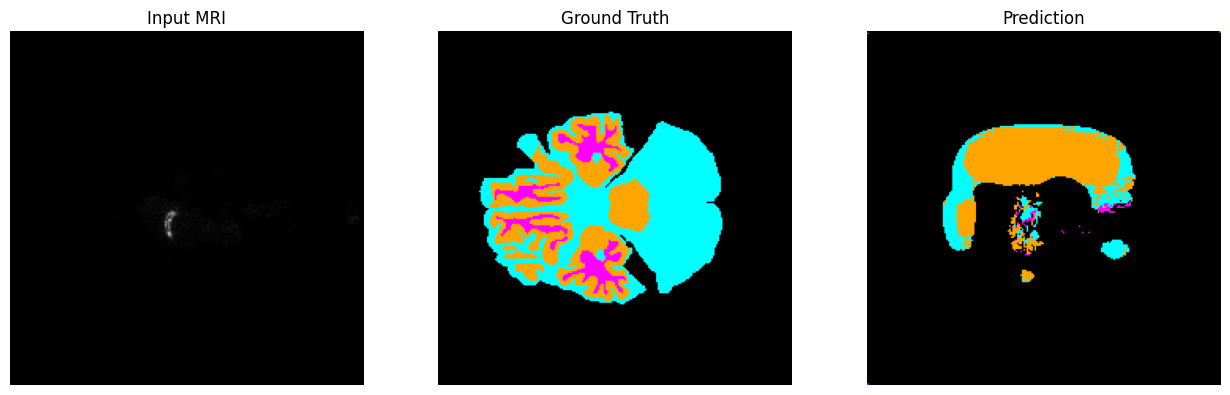

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass improved from 0.22999 to 0.23033, saving model to best_model_vgg16unetpp_mrbrains.keras

Epoch 100: finished saving model to best_model_vgg16unetpp_mrbrains.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - csf_iou: 0.0156 - dice_coefficient_multiclass: 0.1846 - gm_iou: 0.0058 - iou_score_multiclass: 0.1388 - loss: 1.5863 - pixel_accuracy_multiclass: 0.9069 - wm_iou: 2.9120e-04 - val_csf_iou: 0.1017 - val_dice_coefficient_multiclass: 0.3314 - val_gm_iou: 0.1149 - val_iou_score_multiclass: 0.2303 - val_loss: 1.3577 - val_pixel_accuracy_multiclass: 0.7955 - val_wm_iou: 0.0992 - learning_rate: 2.5000e-05

Training time: 13.4 min


In [18]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()
history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)
print(f'\nTraining time: {(time.time()-start_time)/60:.1f} min')

## 13. Training Graphs

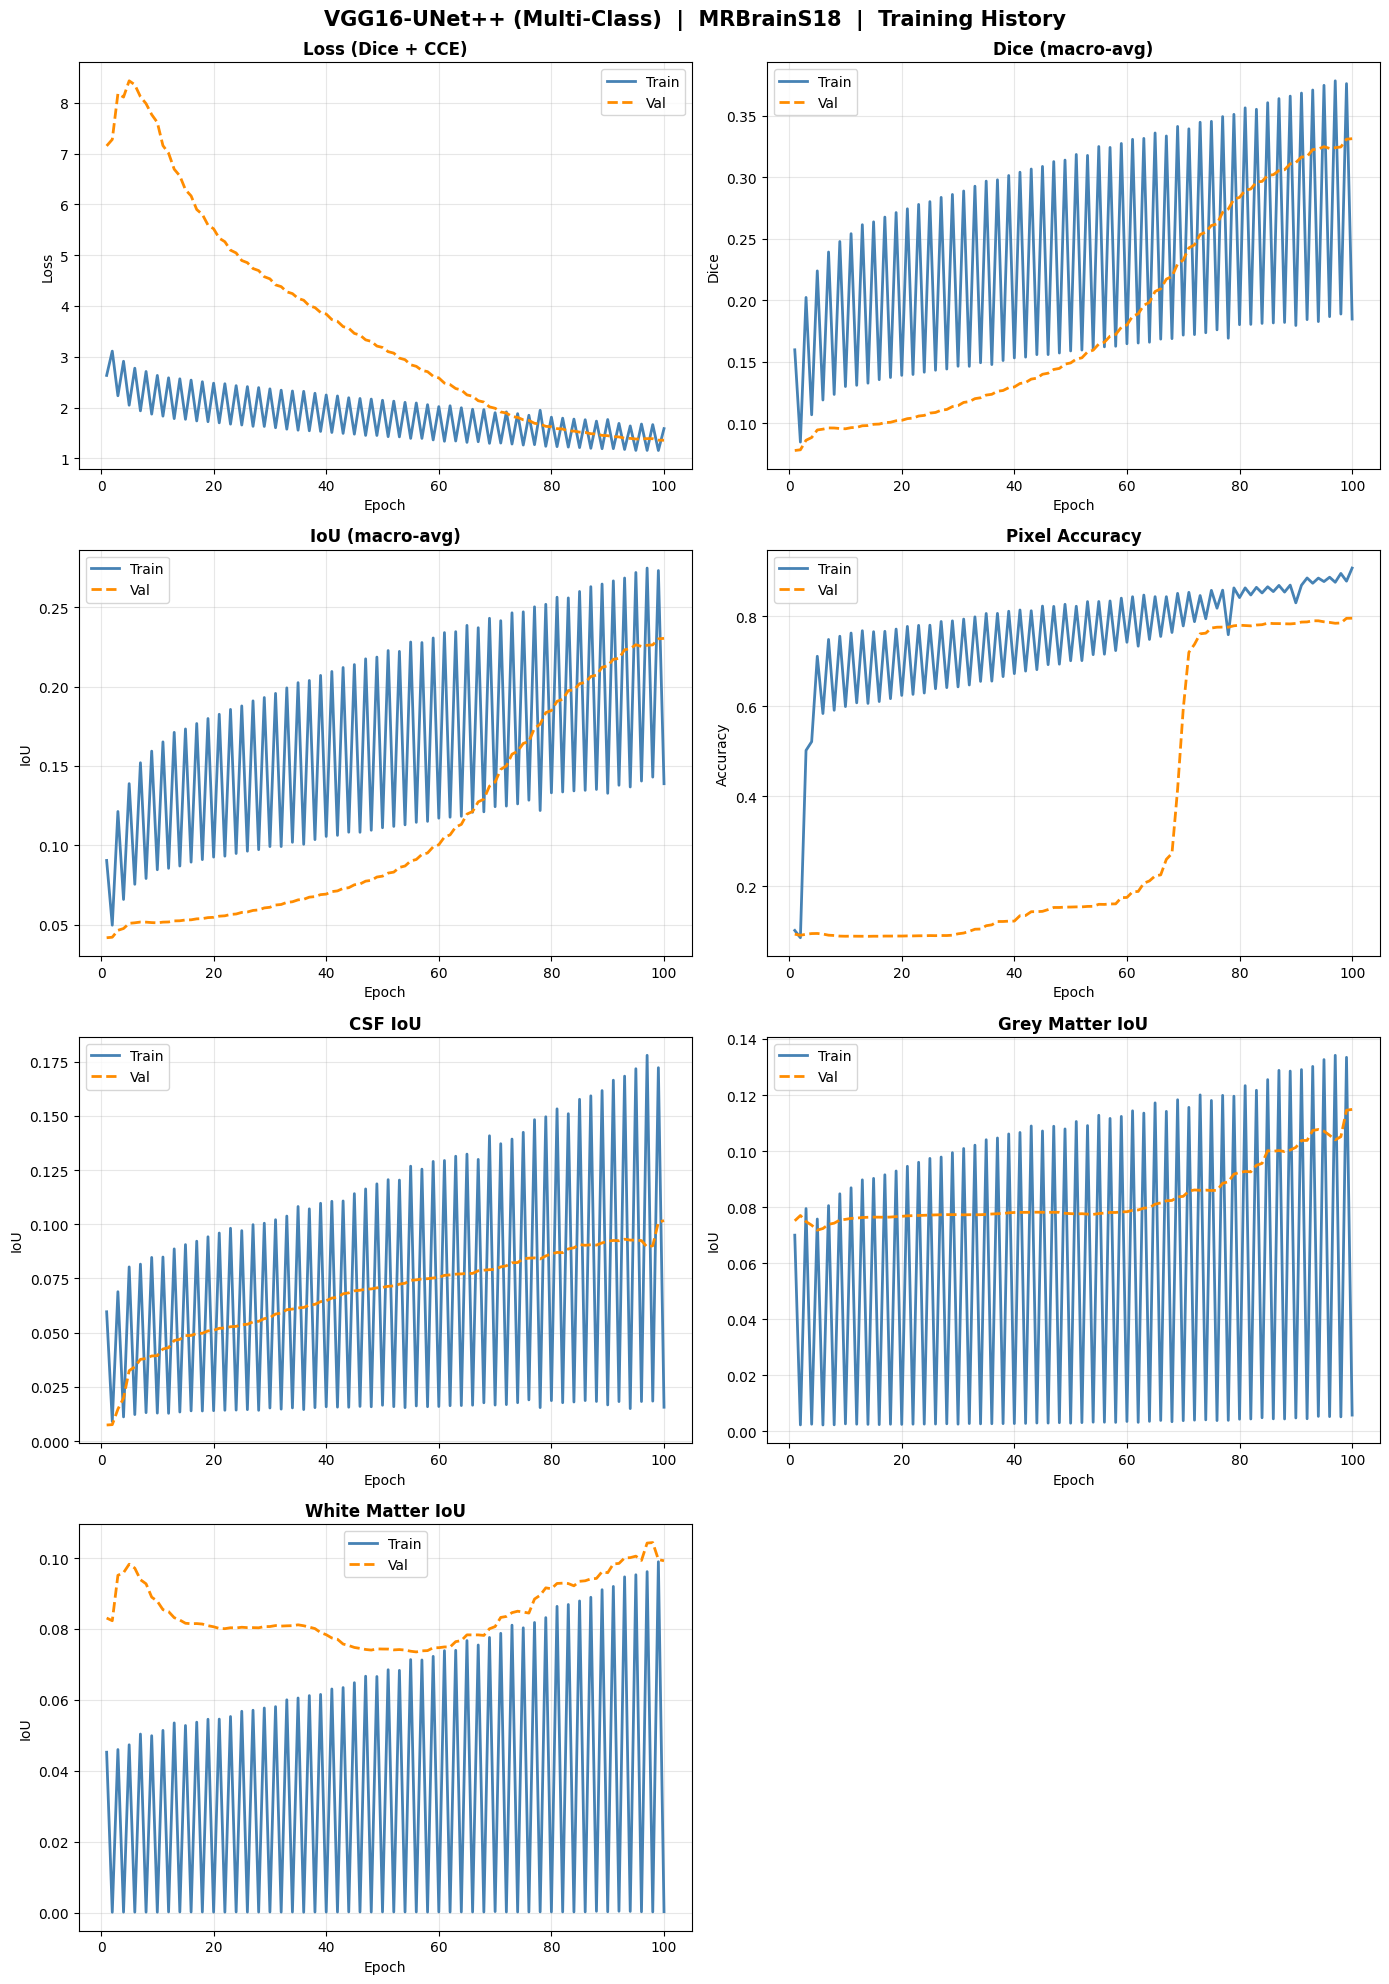

Plot saved ✓


In [19]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('VGG16-UNet++ (Multi-Class)  |  MRBrainS18  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (tk, vk, title, ylabel) in zip(axes.flatten(), plot_specs):
    er = range(1, len(H[tk]) + 1)
    ax.plot(er, H[tk], label='Train', color='steelblue', linewidth=2)
    ax.plot(er, H[vk], label='Val', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_vgg16_unetpp_mrbrains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 14. Best & Average Metrics Table

In [20]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  VGG16-UNet++ Multi-Class  |  MRBrainS18')
print('=' * 68)
print(report.to_string())
print('=' * 68)
best_epoch = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')
report

   BEST & AVERAGE METRICS  —  VGG16-UNet++ Multi-Class  |  MRBrainS18
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  1.1559     1.8302    1.3577   3.6385
Dice (macro-avg)      0.3785     0.2333    0.3314   0.1823
IoU (macro-avg)       0.2746     0.1626    0.2303   0.1106
Pixel Accuracy        0.9069     0.7548    0.7955   0.3304
CSF IoU               0.1779     0.0684    0.1017   0.0678
Grey Matter IoU       0.1342     0.0557    0.1149   0.0836
White Matter IoU      0.0990     0.0348    0.1044   0.0843

Best Val IoU (macro-avg): 0.2303  (epoch 100)
Best Val CSF IoU         : 0.1017
Best Val Grey Matter IoU : 0.1149
Best Val White Matter IoU: 0.1044


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,1.1559,1.8302,1.3577,3.6385
Dice (macro-avg),0.3785,0.2333,0.3314,0.1823
IoU (macro-avg),0.2746,0.1626,0.2303,0.1106
Pixel Accuracy,0.9069,0.7548,0.7955,0.3304
CSF IoU,0.1779,0.0684,0.1017,0.0678
Grey Matter IoU,0.1342,0.0557,0.1149,0.0836
White Matter IoU,0.0990,0.0348,0.1044,0.0843


## 15. Load Best Model & Final Evaluation

In [21]:
best_model = tf.keras.models.load_model(
    'best_model_vgg16unetpp_mrbrains.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')

Best model loaded ✓


In [22]:
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG16-UNet++ | MRBrainS18)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

pd.DataFrame([{
    'Model': 'VGG16-UNet++ (MRBrainS18)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')

1/2 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - csf_iou: 0.1017 - dice_coefficient_multiclass: 0.3314 - gm_iou: 0.1149 - iou_score_multiclass: 0.2303 - loss: 1.3577 - pixel_accuracy_multiclass: 0.7955 - wm_iou: 0.0992

2026-07-05 19:15:46.634433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:15:46.878115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:15:48.657856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:15:48.914135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:15:51.002145: E external/local_xla/xla/stream_

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 9s/step - csf_iou: 0.0713 - dice_coefficient_multiclass: 0.2661 - gm_iou: 0.0668 - iou_score_multiclass: 0.1878 - loss: 1.4161 - pixel_accuracy_multiclass: 0.7687 - wm_iou: 0.0510

  FINAL TEST-SET METRICS  (VGG16-UNet++ | MRBrainS18)
  loss                               : 1.4161
  compile_metrics                    : 0.2661


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
VGG16-UNet++ (MRBrainS18),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

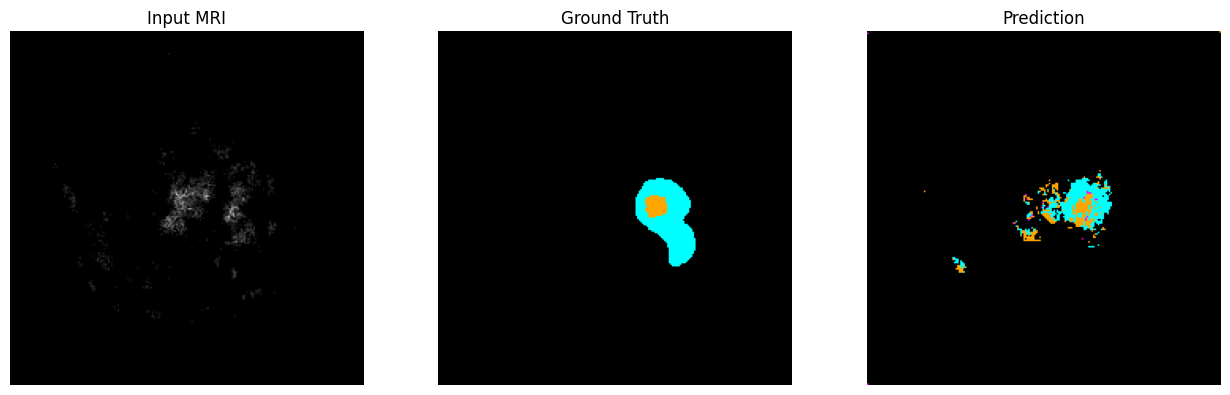

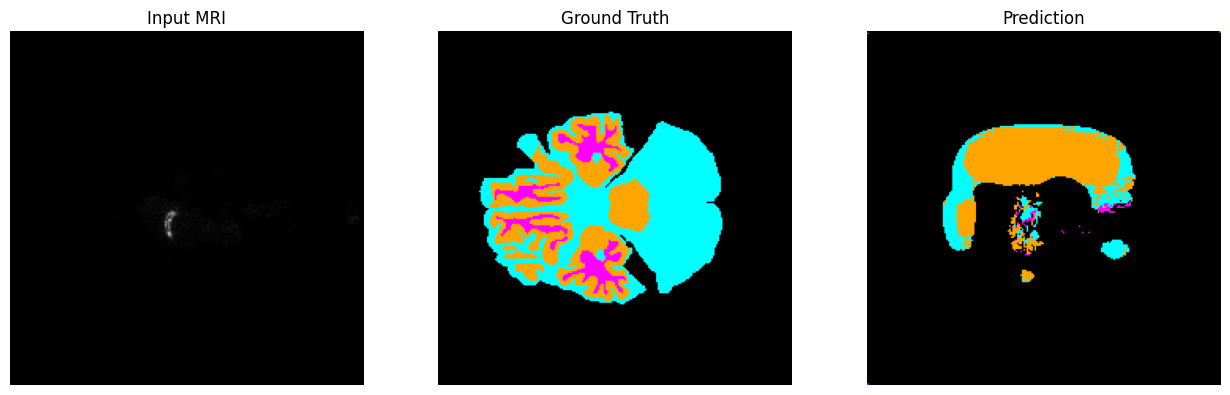

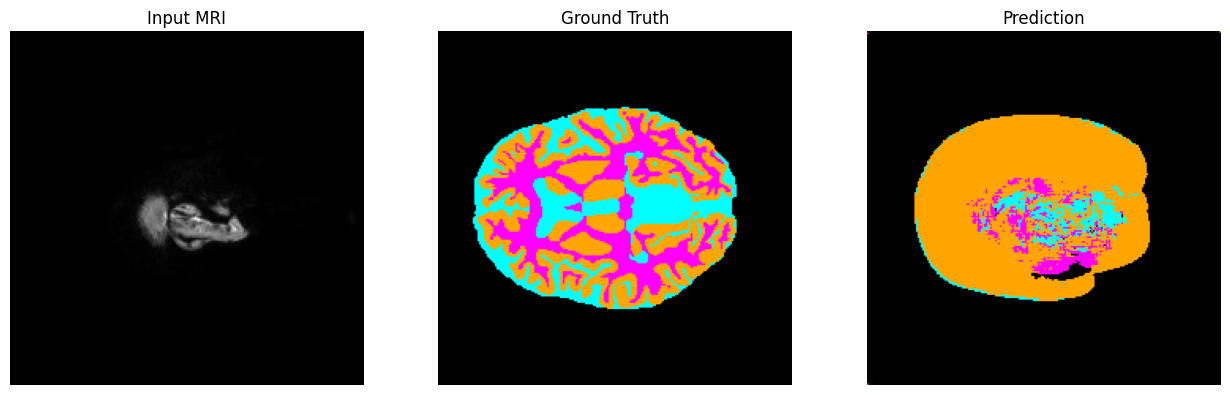

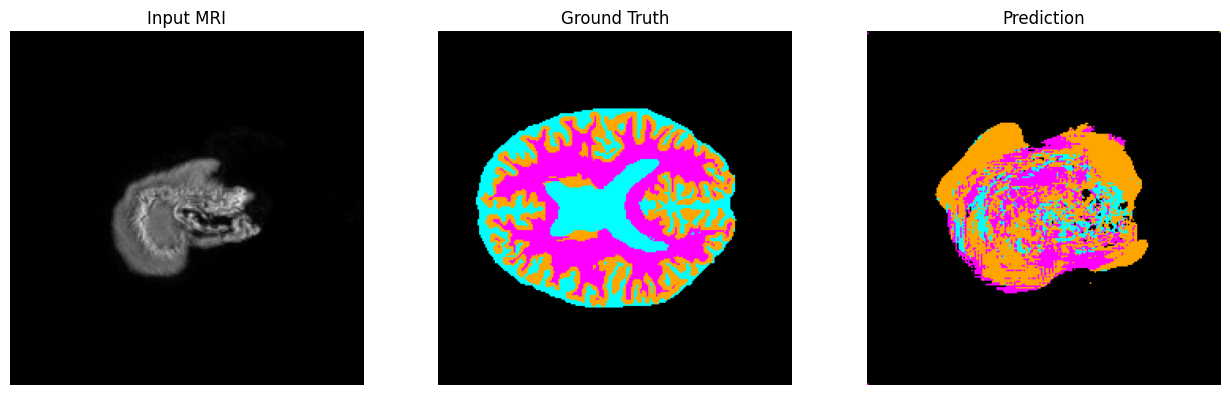

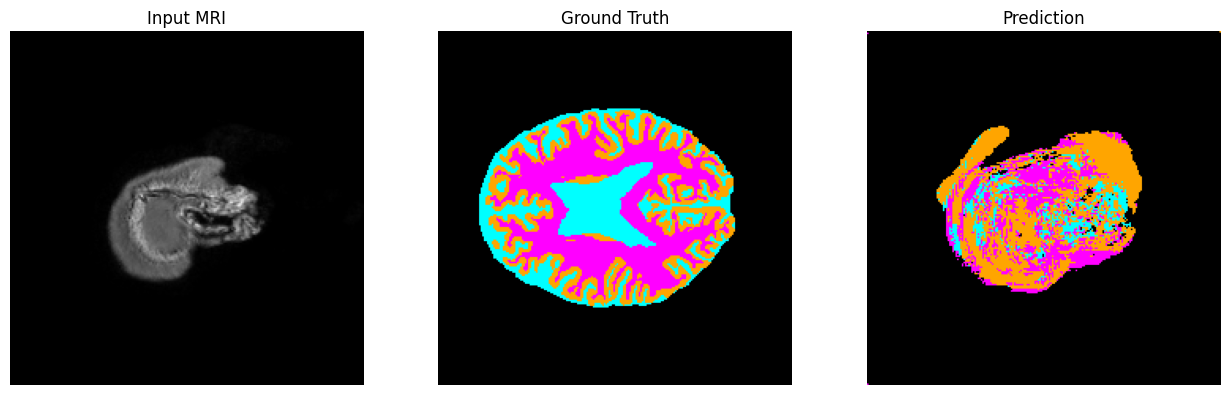

In [23]:
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Save Final Model

In [24]:
best_model.save('mrbrains_vgg16_unetpp_multiclass_final.keras')
print('Model saved ✓')

Model saved ✓
